In [4]:
import pandas as pd

# Replace 'your_dataset.csv' with the actual file name or path to your dataset
file_path =r"C:\Users\anvim\Desktop\PYTHON ASS\machine learning\Bank data for final project.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to understand its structure
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome  \
0  unknown    5   may       261         1     -1         0  unknown   
1  unknown    5   may       151         1     -1         0  unknown   
2  unknown    5   may        76         1     -1         0  unknown   
3  unknown    5   may        92         1     -1         0  unknown   
4  unknown    5   may       198         1     -1         0  unknown   

  y (has the client subscribed a term deposit?)  
0                                            no  
1                           

In [5]:
# Summary statistics for numerical columns
print("Summary statistics for numerical columns:")
print(df.describe())

# Check for missing values and data types
print("\nInformation about data types and missing values:")
print(df.info())

Summary statistics for numerical columns:
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000  

In [6]:
print("Checking for missing values:")
print(df.isnull().sum())

# 2. Handle missing values
# Option 1: Drop rows with missing values (if appropriate)
df = df.dropna()

# Option 2: Fill missing values with suitable methods
# Fill numerical columns with the median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with the mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

# 3. Detect and handle inconsistent data (e.g., typos or case issues in categorical data)
for col in cat_cols:
    print(f"Unique values in '{col}' before cleaning:")
    print(df[col].unique())

    # Convert to lowercase and strip whitespace (example of standardizing text data)
    df[col] = df[col].str.lower().str.strip()

    print(f"Unique values in '{col}' after cleaning:")
    print(df[col].unique())

# 4. Verify missing values are handled
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Save the cleaned dataset (optional)
df.to_csv("cleaned_dataset.csv", index=False)

Checking for missing values:
age                                              0
job                                              0
marital                                          0
education                                        0
default                                          0
balance                                          0
housing                                          0
loan                                             0
contact                                          0
day                                              0
month                                            0
duration                                         0
campaign                                         0
pdays                                            0
previous                                         0
poutcome                                         0
y (has the client subscribed a term deposit?)    0
dtype: int64
Unique values in 'job' before cleaning:
['management' 'technician' 'entrepreneur' 'blue-col

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

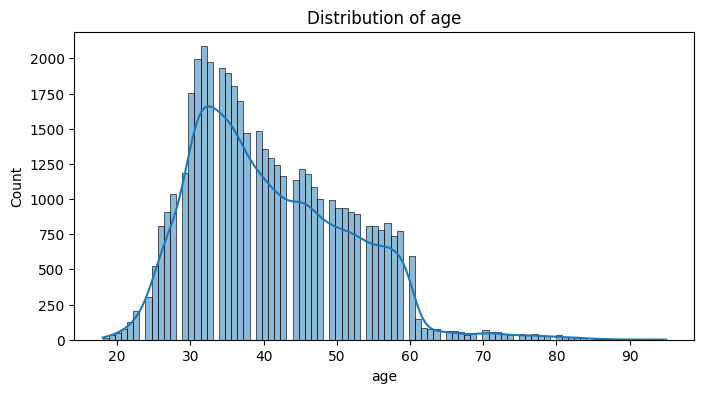

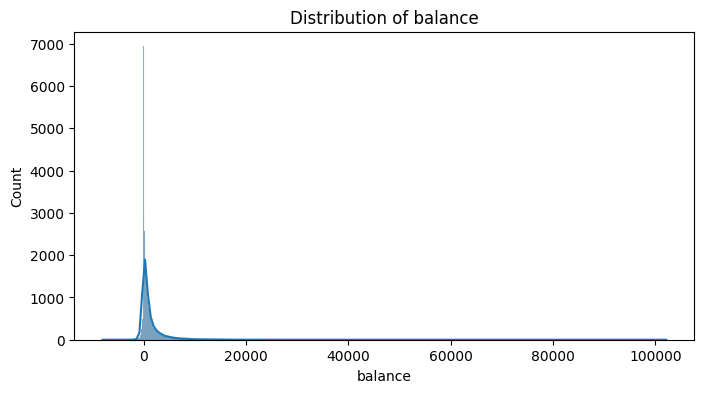

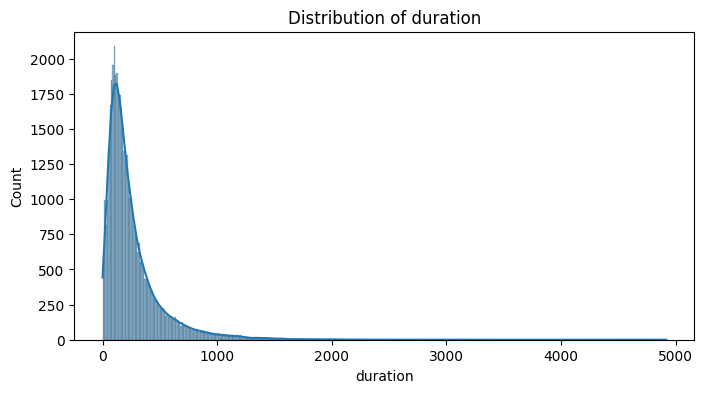

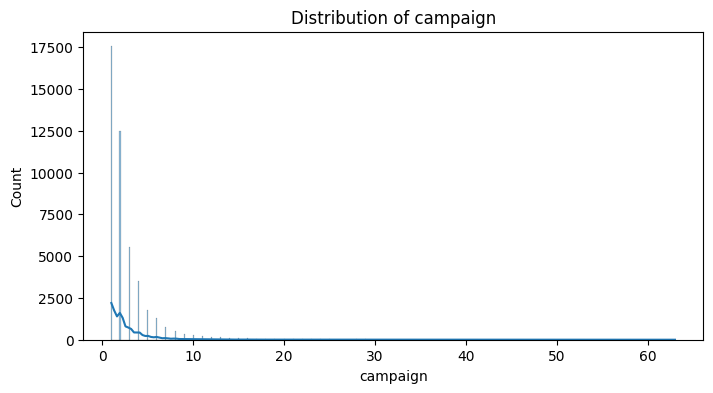

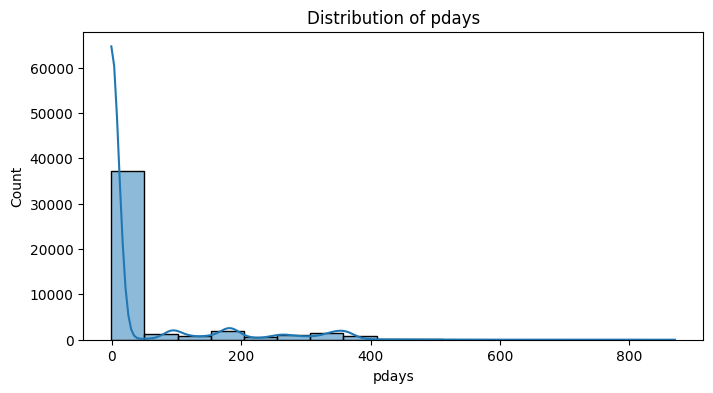

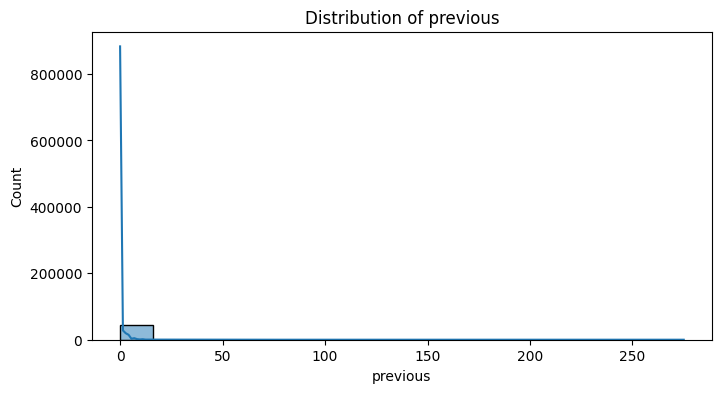

In [10]:
# Numeric columns
numeric_cols = ['age', 'balance', 'duration','campaign','pdays','previous']

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

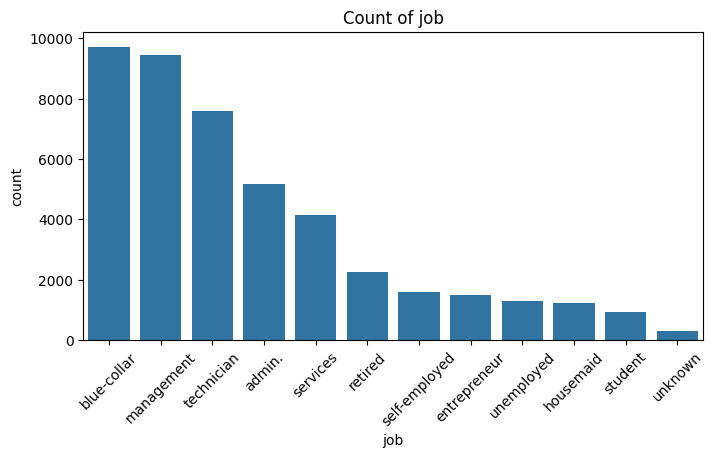

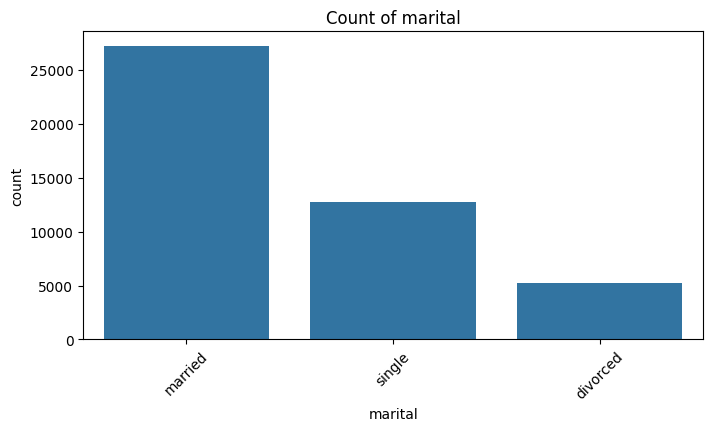

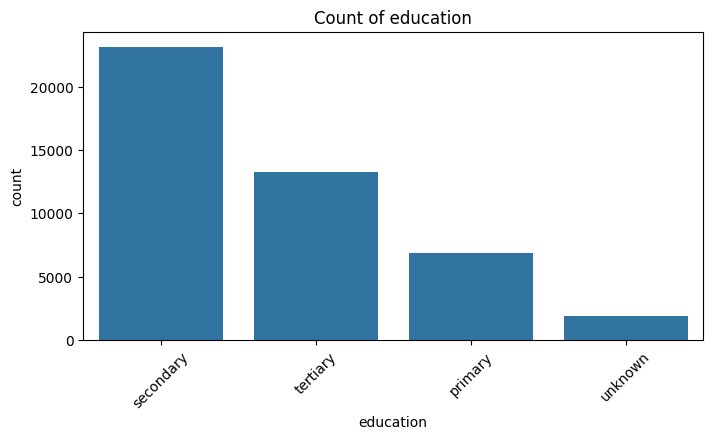

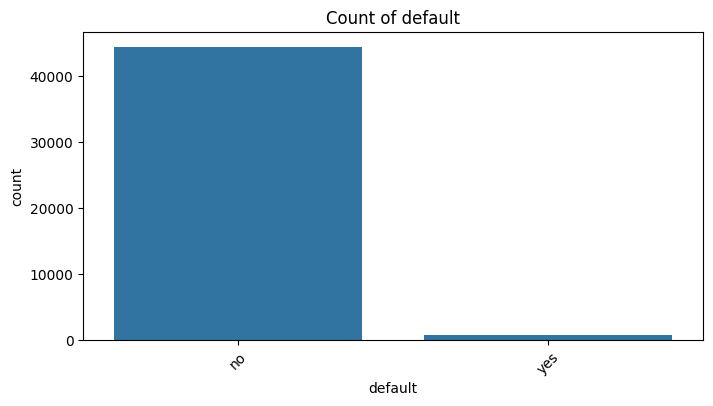

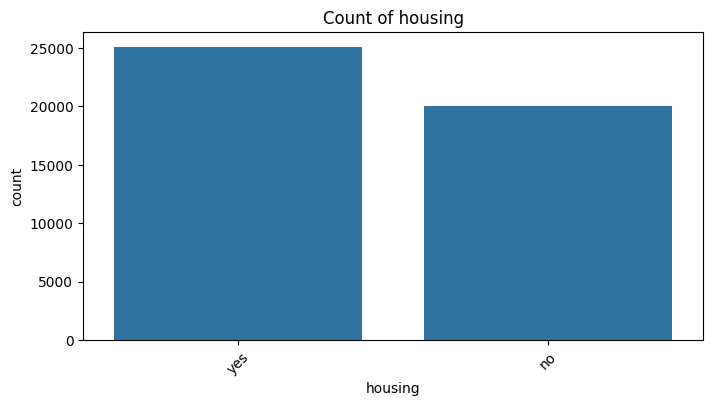

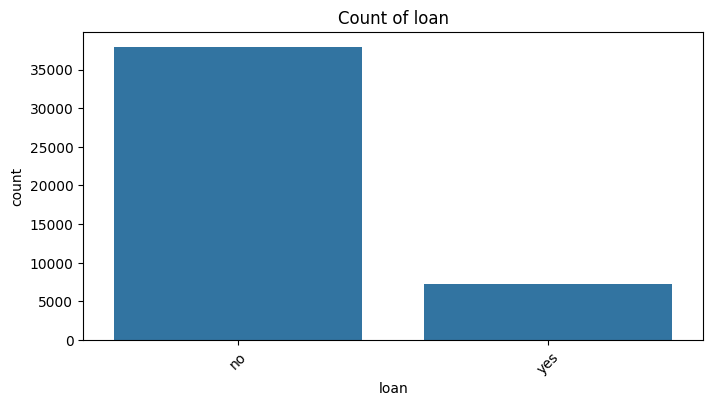

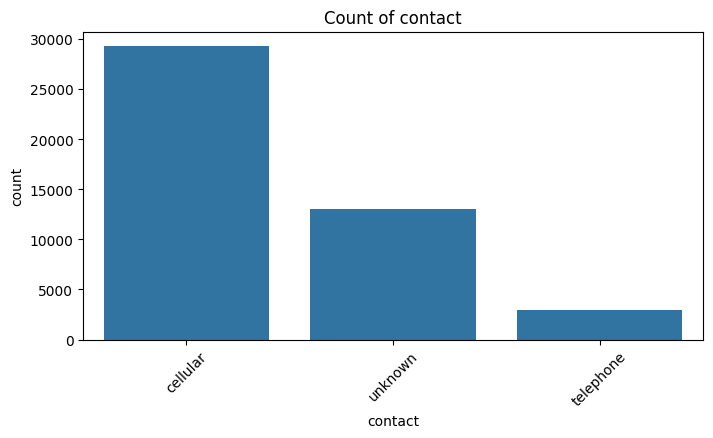

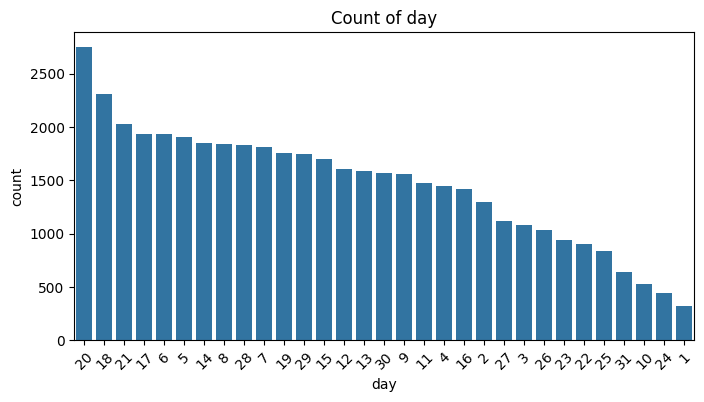

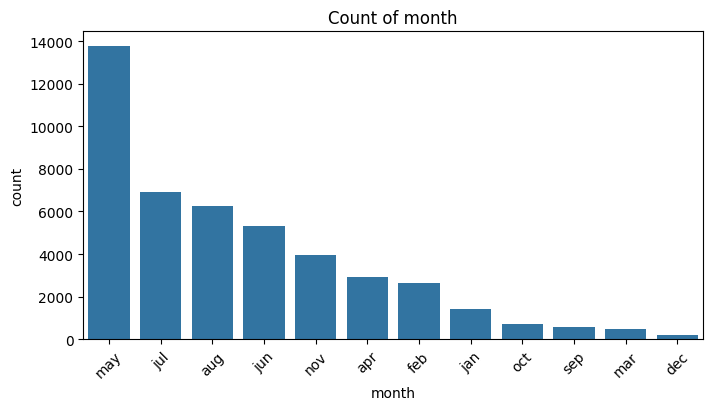

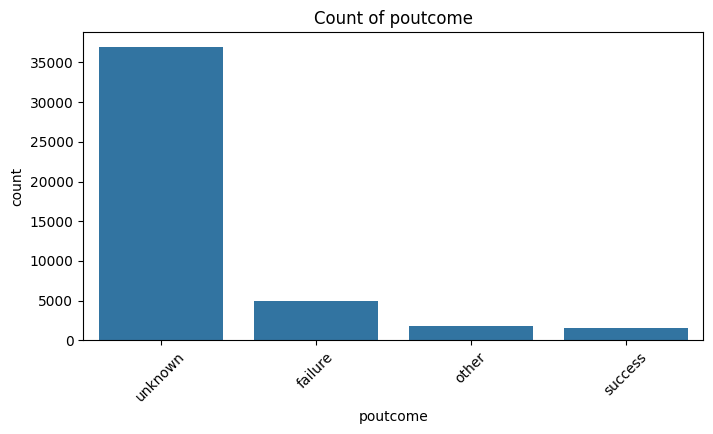

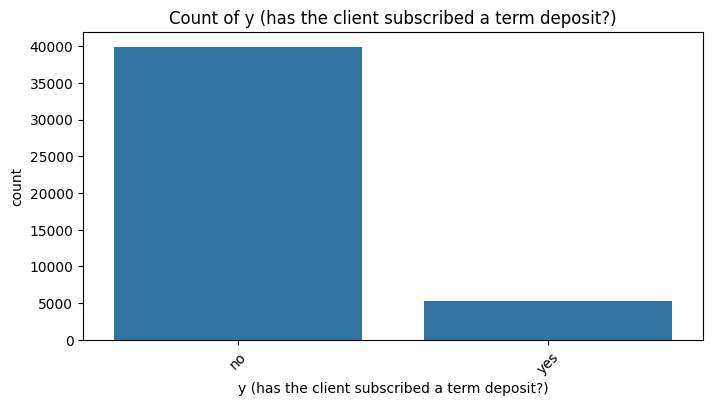

In [13]:
categorical_cols = ['job', 'marital', 'education', 'default','housing', 'loan','contact', 'day', 'month', 'poutcome', 
                    'y (has the client subscribed a term deposit?)']

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [15]:
numeric_df = df.select_dtypes(include='number')

In [16]:
corr_matrix = numeric_df.corr()

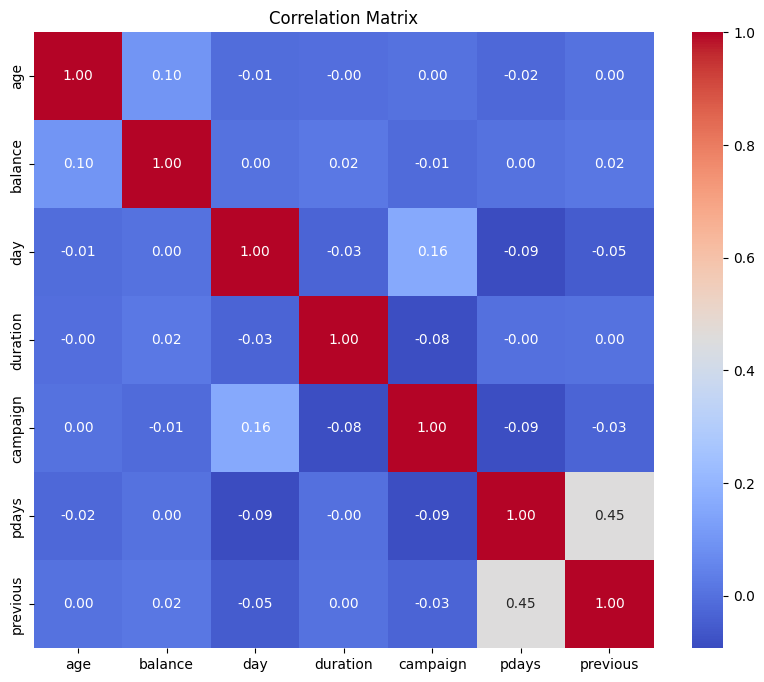

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

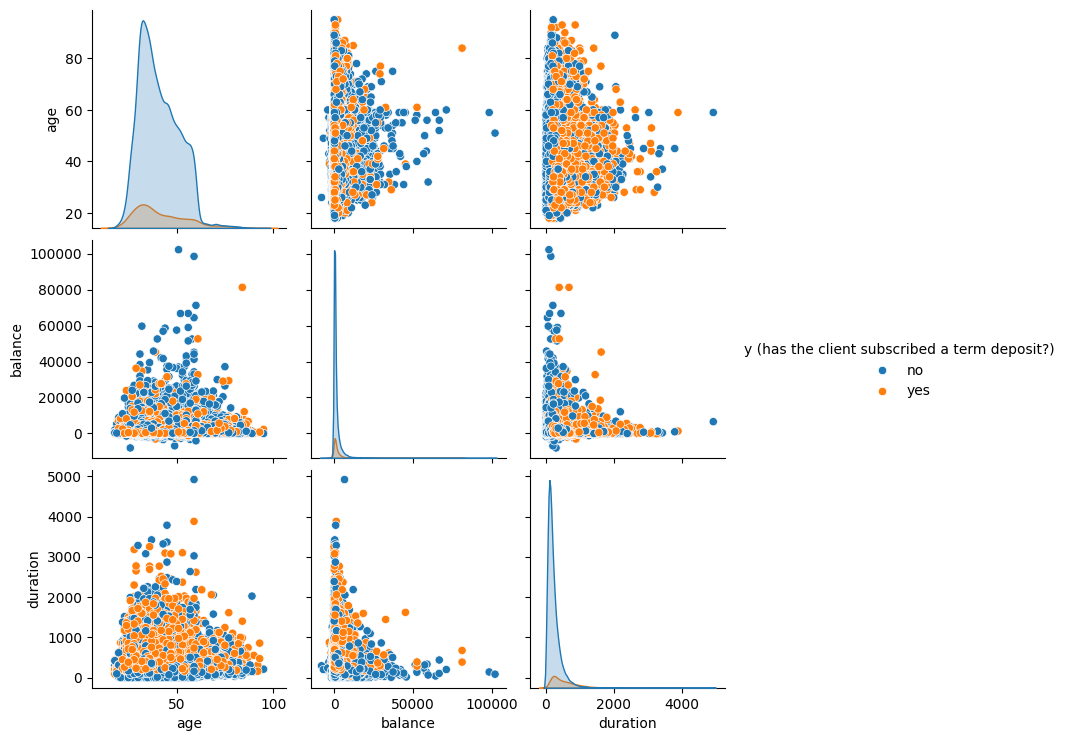

In [19]:
sns.pairplot(df, vars=['age', 'balance', 'duration'], hue='y (has the client subscribed a term deposit?)')
plt.show()

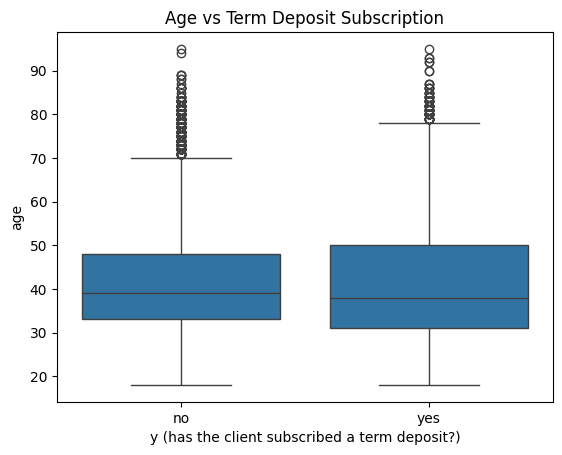

In [21]:
sns.boxplot(x='y (has the client subscribed a term deposit?)', y='age', data=df)
plt.title('Age vs Term Deposit Subscription')
plt.show()

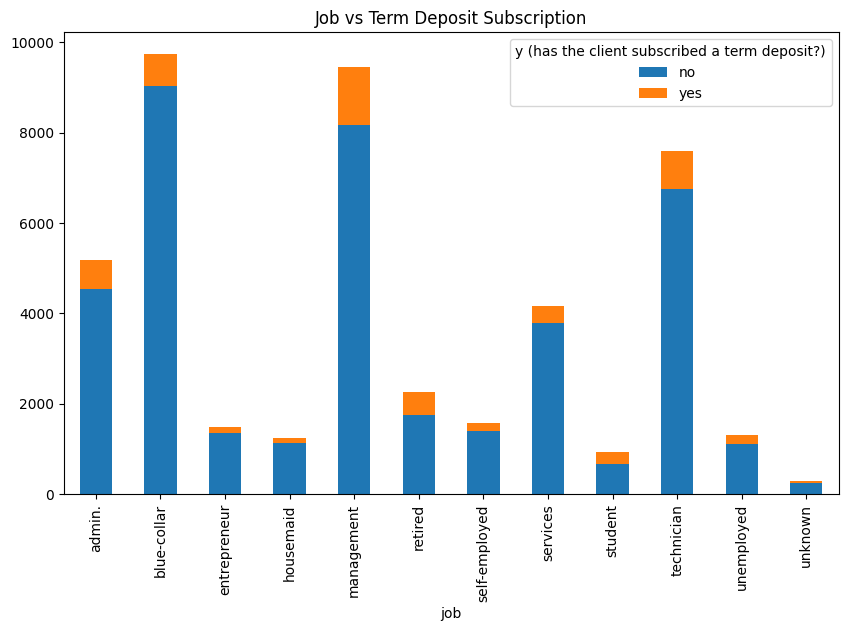

In [23]:
pd.crosstab(df['job'], df['y (has the client subscribed a term deposit?)']).plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Job vs Term Deposit Subscription')
plt.show()

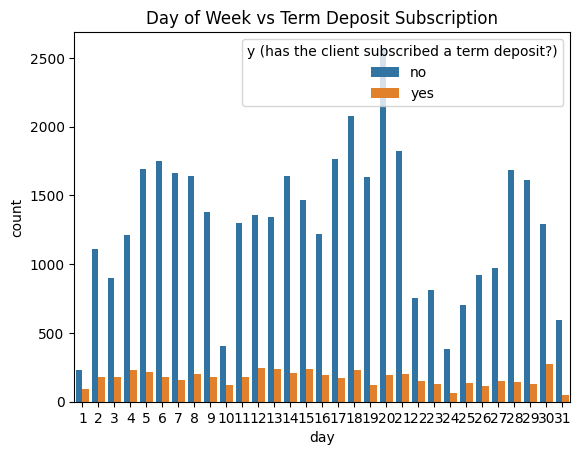

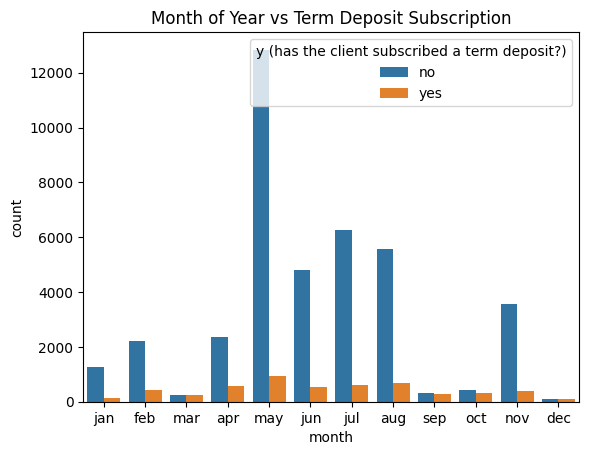

In [30]:
sns.countplot(x='day', hue='y (has the client subscribed a term deposit?)', data=df)
plt.title('Day of Week vs Term Deposit Subscription')
plt.show()

sns.countplot(x='month', hue='y (has the client subscribed a term deposit?)', data=df, 
              order=['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
                     'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])
plt.title('Month of Year vs Term Deposit Subscription')
plt.show()

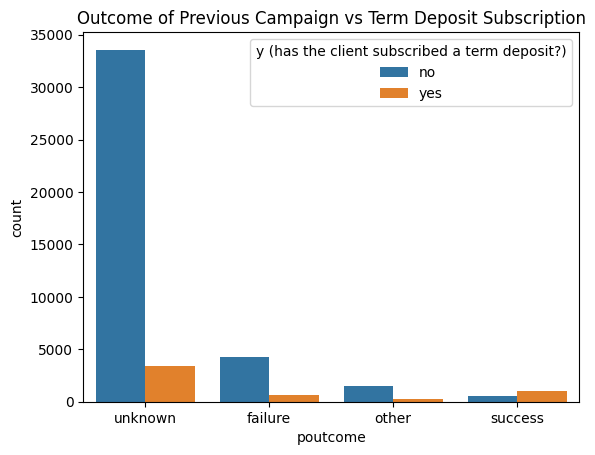

In [31]:
sns.countplot(x='poutcome', hue='y (has the client subscribed a term deposit?)', data=df)
plt.title('Outcome of Previous Campaign vs Term Deposit Subscription')
plt.show()

In [57]:
# Check for duplicates
duplicates = df[df.duplicated()]

# Print duplicates
if not duplicates.empty:
    print("Duplicates found:")
    print(duplicates)
else:
    print("No duplicates found.")


No duplicates found.


In [58]:
unique_education = df['education'].unique()
print("Unique values in 'education':", unique_education)

Unique values in 'education': ['tertiary' 'secondary' 'unknown' 'primary']


In [59]:
unique_job = df['job'].unique()
print("Unique values in 'job':", unique_job)

Unique values in 'job': ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']


In [60]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [62]:
# Specify the columns to check for outliers
columns_to_check = ['age', 'balance', 'duration', 'campaign']  # Numerical columns

# Calculate the Z-scores
z_scores = np.abs((df[columns_to_check] - df[columns_to_check].mean()) / df[columns_to_check].std())

# Define a threshold for identifying outliers (commonly 3)
threshold = 3
outliers = (z_scores > threshold).any(axis=1)

# Separate outliers and non-outliers
outliers_df = df[outliers]
cleaned_df = df[~outliers]

print("Number of outliers detected:", outliers_df.shape[0])
print("Dataset after removing outliers:", cleaned_df.shape)


Number of outliers detected: 2868
Dataset after removing outliers: (42343, 17)


In [63]:
# Save the cleaned dataset if needed
cleaned_df.to_csv("cleaned_dataset.csv", index=False)

In [64]:
# Define a function to remove outliers using IQR
def remove_outliers_iqr(df, columns):
    cleaned_df = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Remove outliers
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]
    return cleaned_df

# Apply to numerical columns
columns_to_check = ['age', 'balance', 'duration', 'campaign']
cleaned_df = remove_outliers_iqr(df, columns_to_check)

print("Dataset after removing outliers:", cleaned_df.shape)

Dataset after removing outliers: (34719, 17)


In [65]:
# Check skewness for numerical columns
numerical_columns = ['age', 'balance', 'duration', 'campaign']
skewness = df[numerical_columns].skew()

print("Skewness of numerical features:")
print(skewness)

Skewness of numerical features:
age         0.684818
balance     8.360308
duration    3.144318
campaign    4.898650
dtype: float64


In [67]:
print(df['balance'].describe())
print(df[df['balance'] < -1])

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64
       age          job   marital  education default  balance housing loan  \
25      44       admin.   married  secondary      no     -372     yes   no   
28      46   management    single  secondary      no     -246     yes   no   
36      25  blue-collar   married  secondary      no       -7     yes   no   
37      53   technician   married  secondary      no       -3      no   no   
45      36       admin.    single    primary      no     -171     yes   no   
...    ...          ...       ...        ...     ...      ...     ...  ...   
44626   31     services    single  secondary      no     -205      no   no   
44629   28  blue-collar    single  secondary      no      -46     yes   no   
44836   33  blue-collar   married    primary      no     -195      no   no   
44908 

In [68]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df['balance_transformed'] = pt.fit_transform(df[['balance']])

In [69]:
# Identify categorical columns
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical features:", categorical_features)

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y (has the client subscribed a term deposit?)']


In [70]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
label_encoder = LabelEncoder()

# Apply Label Encoding to each categorical column
for col in categorical_features:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    4        1          2        0     2143        1     0        2   
1   44    9        2          1        0       29        1     0        2   
2   33    2        1          1        0        2        1     1        2   
3   47    1        1          3        0     1506        1     0        2   
4   33   11        2          3        0        1        0     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  \
0    5      8       261         1     -1         0         3   
1    5      8       151         1     -1         0         3   
2    5      8        76         1     -1         0         3   
3    5      8        92         1     -1         0         3   
4    5      8       198         1     -1         0         3   

   y (has the client subscribed a term deposit?)  balance_transformed  
0                                              0             0.414773  
1       

In [71]:
# One-hot encoding with pandas
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("One-hot encoded dataset:")
print(df_encoded.head())

One-hot encoded dataset:
   age  balance  day  duration  campaign  pdays  previous  \
0   58     2143    5       261         1     -1         0   
1   44       29    5       151         1     -1         0   
2   33        2    5        76         1     -1         0   
3   47     1506    5        92         1     -1         0   
4   33        1    5       198         1     -1         0   

   balance_transformed  job_1  job_2  ...  month_6  month_7  month_8  month_9  \
0             0.414773  False  False  ...    False    False     True    False   
1            -0.410774  False  False  ...    False    False     True    False   
2            -0.431122  False   True  ...    False    False     True    False   
3             0.197685   True  False  ...    False    False     True    False   
4            -0.432119  False  False  ...    False    False     True    False   

   month_10  month_11  poutcome_1  poutcome_2  poutcome_3  \
0     False     False       False       False        True   

In [72]:
df[categorical_features] = df[categorical_features].fillna("Unknown")

In [73]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   age                                            45211 non-null  int64  
 1   job                                            45211 non-null  int64  
 2   marital                                        45211 non-null  int64  
 3   education                                      45211 non-null  int64  
 4   default                                        45211 non-null  int64  
 5   balance                                        45211 non-null  int64  
 6   housing                                        45211 non-null  int64  
 7   loan                                           45211 non-null  int64  
 8   contact                                        45211 non-null  int64  
 9   day                                            452

In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Prepare features and target
X = df.drop("y (has the client subscribed a term deposit?)", axis=1)  # Features
y = df["y (has the client subscribed a term deposit?)"]  # Target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

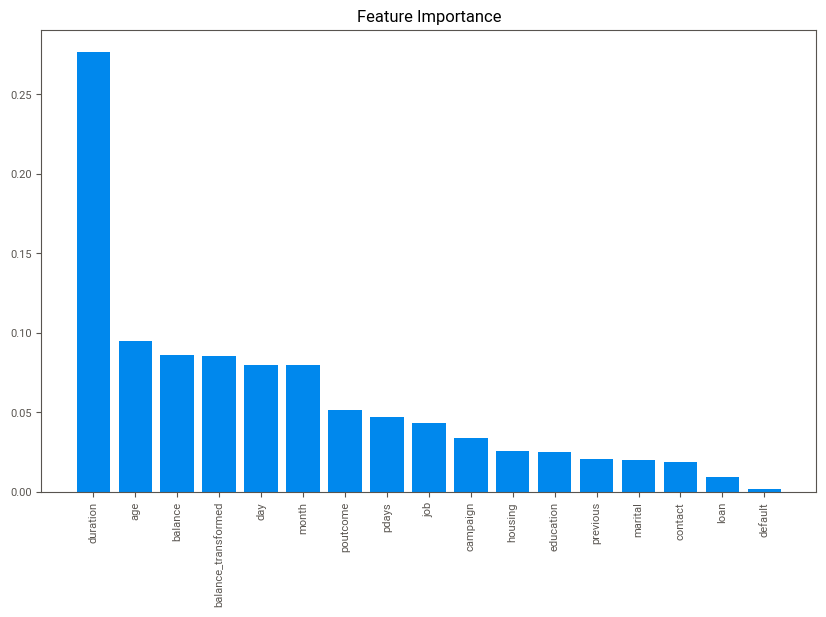

Top 10 features: Index(['duration', 'age', 'balance', 'balance_transformed', 'day', 'month',
       'poutcome', 'pdays', 'job', 'campaign'],
      dtype='object')


In [78]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Train a Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importance scores
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names[indices], rotation=90)
plt.show()

# Select the top N features (e.g., top 10)
top_features = feature_names[indices][:10]
print("Top 10 features:", top_features)

In [79]:
from sklearn.feature_selection import SelectKBest, f_classif

# Apply SelectKBest
selector = SelectKBest(score_func=f_classif, k=10)  # Select top 10 features
X_new = selector.fit_transform(X_train, y_train)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print("Selected features using SelectKBest:", selected_features)

Selected features using SelectKBest: Index(['education', 'housing', 'loan', 'contact', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'balance_transformed'],
      dtype='object')
